<div style="background-color:rgba(250, 250, 250, 0.1)">

---
### Demoblatt
# 📈  `Trainieren eines Modells`

#### Inhalt
- Beispiel einer simplen linearen Regression
- Trainieren mit ALLEN Datensätzen
- Trainieren mit Trainings- und Testdaten

---
<div style="text-align: center; background-color: #2f302eff; color: #e6e6e3d8; padding: 8px; border-radius: 6px;">©2025 Prof. Gaisberger</div>

---
</div>

### Lineare Regression
Bei der Linearen Regression versucht man ein Modell zu erstellen, welches ``eine Gerade`` möglichst so zwischen die Daten zu legen, dass ``die Abweichung aller tatsächlichen Werte möglichst gering`` ist. Die Punkte der Geraden entsprechen den Vorhersagen des Modells.

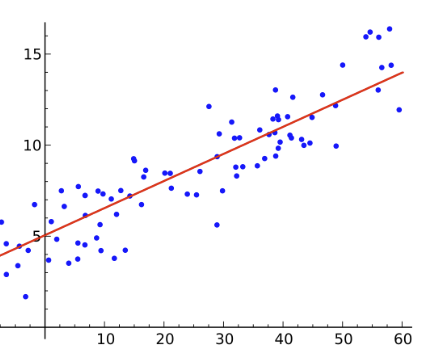

Je nachdem welches Modell verwendet wird bzw. wie ein Modell trainiert wird, passen sich seine Vorhersagen an die tatsächlichen Werte an. Dabei können folgende Situatione auftreten:

>- ``Underfitting:``  
>Das Modell ist sehr ungenau und passt sich wenig an die Trainingsdaten an.
>- ``Overfitting:``  
>Das Modell passt sich zu gut an die Trainingsdaten an und die Vorhersagen bei neuen Daten ist meistens schlechter.
>- ``Optimal:``  
>Ist ein Kompromiss, so dass die Genauigkeit bei Trainings- und Testdaten möglichst hoch ist.

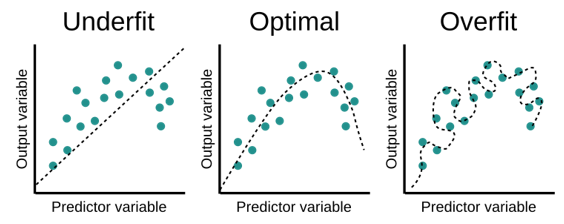

- Je ``geringer`` die Abweichung des Modells bei den ``Trainingsdaten`` wird (Overfitting), 
- umso mehr ``steigt`` wiederum die Abweichung bei ``Testdaten`` bzw. neuen Daten (Out-of-Sample).

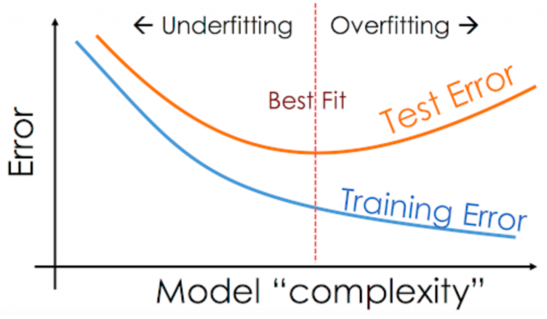

<div style="background-color:rgba(250, 250, 0, 0.1)">

---

# Aufgabe: 

Aus der ``Sepal-Länge`` einer Iris soll die ``Petal-Länge`` voraus gesagt werden.  
Dazu wird ein Modell erstellt, welches anhand einer Geraden die Petal Länge ermittelt. Dieses Modell ist eine **``LINEARE REGRESSION``** und verwendet die Geradengleichung der Mathematik.

>#####  $ f(x) = k x + d $

Das Modell soll dabei so trainiert werden, dass die vorhergesagten Werte eine möglichst geringe Abweichung zu den echten Werten besitzen. 

- In ``Variante 1`` wird zuerst das Modell mit ALLEN Daten trainiert und
- in ``Variante 2`` werden die Daten in Trainings- und Testdaten aufgeteilt

---

---
# 🟨 ``Schritt 1:`` Daten laden

Zuerst werden die Daten in den Hauptspeicher geladen. Im Beispiel wird die Funktion `sklearn.datasets.load_iris` verwendet. Es ist ein Übungsdataset, welches von `sklearn` zur Verfügung gestellt wird. Es wird in einem internen Format geladen und muss danach in ein `Dataframe` umgewandelt werden.

In [ ]:
from sklearn import datasets
import pandas as pd

# Laden der Daten
iris = datasets.load_iris()

# Neues DataFrame mit den Iris-Daten (Features) erzeugen
dfIris = pd.DataFrame(iris.data, columns = iris.feature_names)

dfIris['species'] = iris.target
dfIris['speciesname'] = dfIris['species'].replace({0:'setosa',1:'versicolor', 2:'virginica'})

dfIris

---
## 🔷 `Variante 1:` Trainieren mit dem gesamten Dataset


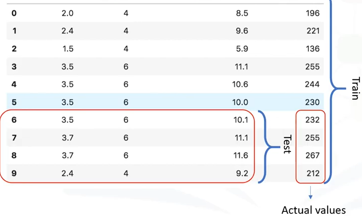

In [ ]:
#------------------------------------------------------------
# Features auswählen
daten_x = dfIris[['sepal length (cm)']].values     # independent
daten_y = dfIris['petal length (cm)'].values       # dependent: Wert der vorausgesagt werden soll

print(daten_y[:5])

In [ ]:
from sklearn import linear_model

# Modell erstellen
model = linear_model.LinearRegression()

# Modell trainieren
model.fit(daten_x, daten_y)


Mit dem trainierten Modell können nun für alle Sepal-Längen der Trainingsdaten die entsprechenden Petal-Längen vorausgesagt und danach mit den echten Werten verglichen werden. 

In [ ]:
pred_y = model.predict(daten_x)

print(pred_y[:5])

In [ ]:
import seaborn as sns

# Echte Werte ausgeben
sns.scatterplot( x=daten_x[:,0], y=daten_y, color='blue', label="Echte Werte")

# Dazu die Vorausgesagten Werte ausgeben
sns.scatterplot( x=daten_x[:,0], y=pred_y,  color='red',  label="Vorhersagen")


## 🔷 Genauigkeit des Modells
Nun kann die Abweichung zwischen den Vorhersagen und den wahren Werten ermittelt werden. Je kleiner diese Abweichung ist, umso besser ist das Modell.
Ziel ist es, dass der Fehler möglichst gering ist und die Gerade die Daten somit möglichst gut abbildet. Die im Folgenden verwendete Funktion wird `Mean Squared Error` genannt.



In [ ]:
from sklearn import metrics

# Mittlere quadratische Abweichung ermitteln
# ACHTUNG: Das ist kein Prozentwert für die Genauigkeit
print( "\nAbweichung der Vorhersagen:") 
print("\tMSE: %.2f"      % metrics.mean_squared_error(daten_y , pred_y) )


#### Probleme:
> - Das Modell ist sehr genau für die Trainingsdaten und neigt zum **``OVERFITTING``**
>
> - Keine Aussage möglich wie genau das Modell  bei Out-of-Sample Daten ist



---
## 🔷 `Variante 2:` Dataset in Trainings- und Testdaten aufteilen

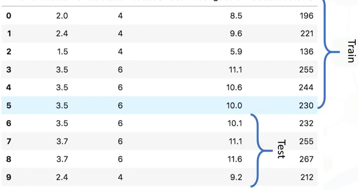

In [ ]:
from sklearn.model_selection import train_test_split

#------------------------------------------------------------
train_size = 0.7
dfTrain, dfTest = train_test_split( dfIris,
                train_size= train_size, 
                random_state=0)
                
#------------------------------------------------------------
# Features auswählen
cols_x  = ['sepal length (cm)']        # independent
cols_y  = 'petal length (cm)'          # dependent: Vorhersagen

train_x = dfTrain[cols_x].values       # independent
train_y = dfTrain[cols_y].values       # dependent

test_x  = dfTest [cols_x].values       # independent
test_y  = dfTest [cols_y].values       # dependent
# -----------------------------------------------------------

print(train_y[:5])

In [ ]:
from sklearn import linear_model

# Modell erstellen
model = linear_model.LinearRegression()

# Modell trainieren
model.fit(train_x, train_y)


### Genauigkeit der ``Trainingsdaten``

Zum Ermitteln der Genauigkeit werden nun für alle Sepal-Längen NUR der Trainingsdaten die entsprechenden Petal-Längen vorausgesagt und danach mit den echten Werten verglichen werden.
 

In [ ]:
# für die Sepal-Längen der Trainingsdaten lassem wir uns die Petal-Längen voraussagen
# um sie danach mit den echten Werten der Trainingsdaten vergleichen zu können
pred_train_y = model.predict(train_x)

print(pred_train_y[:5])

In [ ]:
import seaborn as sns

# Daten ausgeben
sns.scatterplot( x=train_x[:,0], y=train_y, color='blue', label="Echte Werte")
sns.scatterplot( x=train_x[:,0], y=pred_train_y,  color='red',  label="Vorhersagen")


In [ ]:
from sklearn import metrics

# MSE 
print( "\nAbweichung der Vorhersagen der Trainingsdaten:") 
print("\tMSE: %.2f"      % metrics.mean_squared_error(train_y , pred_train_y) )


### Genauigkeit der ``Testdaten``

Nun wird zum Evaluieren auch **``die Genauigkeit der TESTDATEN``** ermittelt und dazu für alle Sepal-Längen der Testdaten die entsprechenden Petal-Längen vorausgesagt. Diese Voraussagen werden danach mit den echten Werten verglichen werden.
 

In [ ]:
pred_test_y = model.predict(test_x)

print(pred_test_y[:5])

In [ ]:
import seaborn as sns

# Daten ausgeben
sns.scatterplot( x=test_x[:,0], y=test_y, color='blue', label="Echte Werte")
sns.scatterplot( x=test_x[:,0], y=pred_test_y,  color='red',  label="Vorhersagen")


In [ ]:
from sklearn import metrics

# MSE 
print( "\nAbweichung der Vorhersagen der Testdaten:") 
print("\tMSE: %.2f"      % metrics.mean_squared_error(test_y , pred_test_y) )


<div style="background-color:rgba(250, 0, 0, 0.1)">

---
**Vergleiche die Genauigkeit beider Trainingsvarianten und beschreibe was du daraus erkennen kannst.**<br>

(Füge hier deine Antwort ein!) 

---
</div>